In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Housing.csv")

# 1. Display first 10 rows
display(df.head(10))

# 2. Check rows and columns
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# 3. Identify Target and Features
target_col = 'price'
feature_cols = [col for col in df.columns if col != target_col]
print(f"Target Column: {target_col}")
print(f"Feature Columns: {feature_cols}")

# 4. Check for missing values
print("\nMissing Values per column:")
print(df.isnull().sum())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


Dataset Shape: 545 rows, 13 columns
Target Column: price
Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing Values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [3]:
# 1. Handle Missing Values
# (No missing values were found in this dataset, but if there were, we would use df.fillna() or df.dropna())

# 2. Remove duplicate rows
dup_count = df.duplicated().sum()
print(f"Duplicate rows found & removed: {dup_count}")
df.drop_duplicates(inplace=True)

# 3. Convert categorical columns to numeric form
# Convert yes/no fields into 1 and 0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# One-hot encoding for 'furnishingstatus'
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print("\nData ready for modeling. Columns after encoding:")
print(list(df.columns))

Duplicate rows found & removed: 0

Data ready for modeling. Columns after encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Split the data (80% training, 20% testing)
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train and evaluate Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("--- Linear Regression Performance ---")
print(f"MAE:  {mean_absolute_error(y_test, lr_preds):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_preds)):,.2f}")
print(f"R² Score: {r2_score(y_test, lr_preds):.4f}\n")

# 3. Train and evaluate Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("--- Random Forest Regressor Performance ---")
print(f"MAE:  {mean_absolute_error(y_test, rf_preds):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):,.2f}")
print(f"R² Score: {r2_score(y_test, rf_preds):.4f}")

--- Linear Regression Performance ---
MAE:  970,043.40
RMSE: 1,324,506.96
R² Score: 0.6529

--- Random Forest Regressor Performance ---
MAE:  1,022,560.05
RMSE: 1,401,496.84
R² Score: 0.6114


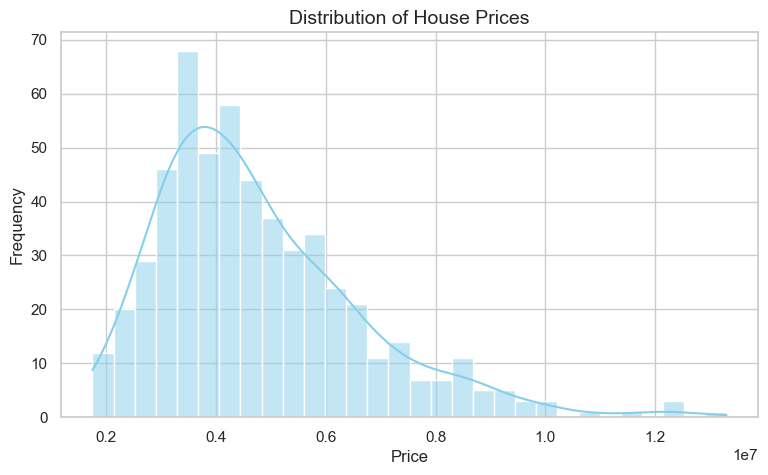

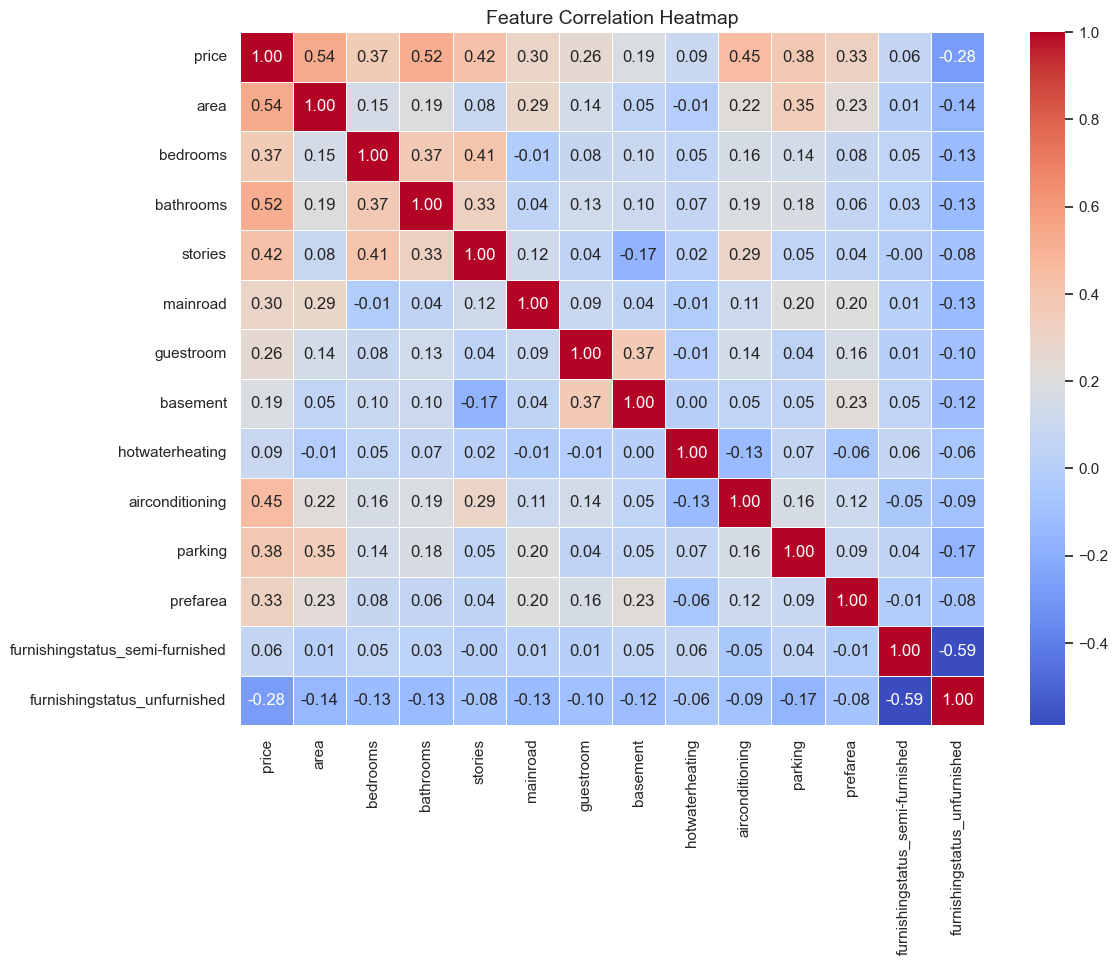

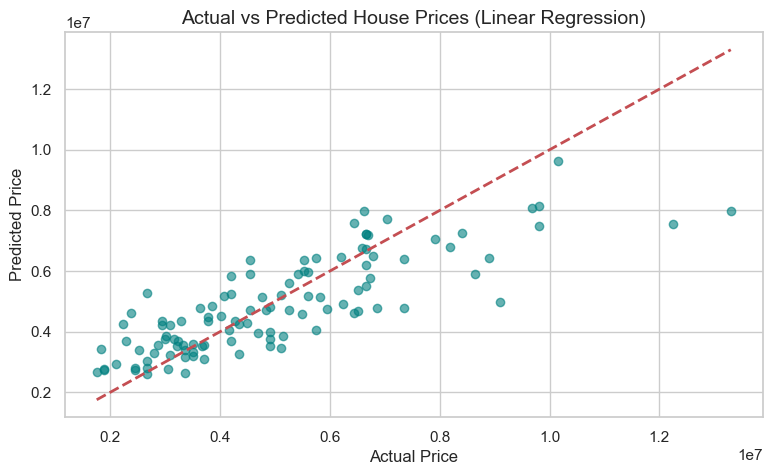

In [7]:
sns.set_theme(style="whitegrid")

# Chart 1: Histogram showing the distribution of house prices
plt.figure(figsize=(9, 5))
sns.histplot(df['price'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of House Prices', fontsize=14)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Chart 2: Correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()

# Chart 3: Actual vs. Predicted price scatter plot
plt.figure(figsize=(9, 5))
plt.scatter(y_test, lr_preds, alpha=0.6, color='teal')
# Draw a perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted House Prices (Linear Regression)', fontsize=14)
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.show()

Feature Importance: By analyzing the data, the total property area is by far the strongest driver of house prices, contributing nearly 47% of the predictive importance, followed closely by the number of bathrooms (15%).
Model Accuracy: In plain terms, our models capture a good portion of the overall trends but aren't perfectly precise. The Linear Regression model actually performed slightly better here, correctly explaining about 65.3% (R² = 0.65) of the fluctuation in house prices. The typical estimation error was off by roughly $970,000 (MAE) per house on average.
Data Surprise: Surprisingly, being located on the mainroad had almost no statistical impact on the predictive capability of the model (only ~1.0% feature importance), despite location usually being a massive factor in real estate.
Business Recommendation: For a real estate business looking to optimize property value or estimate sales accurately, agents should prioritize marketing the square footage and bathroom count, while properties with air conditioning should be highlighted as premium value-adds since it significantly impacts the price more than extra bedrooms or guest rooms do.